<a href="https://colab.research.google.com/github/M-AyyanAsif/NETSOL_TASKS/blob/main/02_EDA_Worksheet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 EDA Worksheet — Auto-MPG Dataset
**Student Name:**  Muhammad Ayyan  |  **Date:** 9-15-2025

Complete every `# TODO` cell. Run the cells in order.  
Answer the written questions in the Markdown cells provided.

---
**Dataset:** Auto-MPG (UCI) | 398 rows × 9 columns


## Task 1 — Import Libraries

In [1]:
# TODO: Import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn  as sns

sns.set_theme(style = 'whitegrid', palette = 'muted')
plt.rcParams['figure.figsize'] = (10,5)
pd.set_option('display.max_columns', None)
print("Libraries Loaded")
# Also set sns theme to 'whitegrid' and default figure size to (10,5)



Libraries Loaded


## Task 2 — Load & Inspect Data

In [2]:
# TODO: Load the Auto-MPG dataset from the UCI repository URL below.
# Column names: ['mpg','cylinders','displacement','horsepower','weight',
#                'acceleration','model_year','origin','car_name']
# Missing values are marked with '?'
# URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
col_names = ['mpg','cylinders','displacement','horsepower','weight',
             'acceleration','model_year','origin','car_name']

df = pd.read_csv(url, sep = '\s+', names= col_names, na_values='?')

print("Shape:", df.shape)
df.head()


<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_867/2580443198.py:11: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(url, sep = '\s+', names= col_names, na_values='?')


Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [3]:
# TODO: Print df.info() to inspect dtypes and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [4]:
# TODO: Print df.describe() to view summary statistics
df.describe()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


**Q1.** How many rows and columns does the dataset have?  
**Answer:** (398,9)

**Q2.** Which column contains missing values and how many?  
**Answer:** (horsepower,6)


## Task 3 — Pre-Processing

In [5]:
# TODO: Check and print missing values per column
# Then drop all rows that contain NaN values (they are < 2% of data)

print("Misssing values per column:\n", df.isna().sum())
df.dropna(inplace=True)
print("\n Shape after droppping:", df.shape)

Misssing values per column:
 mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

 Shape after droppping: (392, 9)


In [6]:
# TODO: Check for and remove duplicate rows

print("Duplicated rows: ",df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Rows after removing the duplicates: ",df.shape)


Duplicated rows:  0
Rows after removing the duplicates:  (392, 9)


In [7]:
# TODO:
# 1. Convert 'cylinders' and 'model_year' to category dtype
cat_cols = ['cylinders', 'model_year']
df[cat_cols] =  df[cat_cols].astype('category')

# 2. Map 'origin' from {1,2,3} to {'usa','europe','japan'}
df['origin'] = df['origin'].map({1:'usa', 2:'europe', 3:'japan'})

# 3. Strip & lowercase 'car_name'
df['car_name'] = df['car_name'].str.strip().str.lower()



In [8]:
# TODO: Create two lists:
# cat_cols — categorical column names (cylinders, origin, model_year)
# num_cols — numerical column names (mpg, displacement, horsepower, weight, acceleration)

cat_cols = ['cylinders', 'origin', 'model_year']   # fill in
num_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']   # fill in


## Task 4 — Feature Engineering

In [9]:
# TODO: Create 'mpg_level' column using pd.cut()
# Bins: [0,17) → 'low', [17,29) → 'medium', [29, max] → 'high'

df['mpg_level'] = pd.cut(df['mpg'], bins=[0, 17, 29, float('inf')], labels=['low', 'medium', 'high'], right=False)

In [10]:
# TODO: Create 'car_company' by extracting the first word from 'car_name'

df['car_company'] = df['car_name'].str.split().str[0]

## Task 5 — Categorical EDA

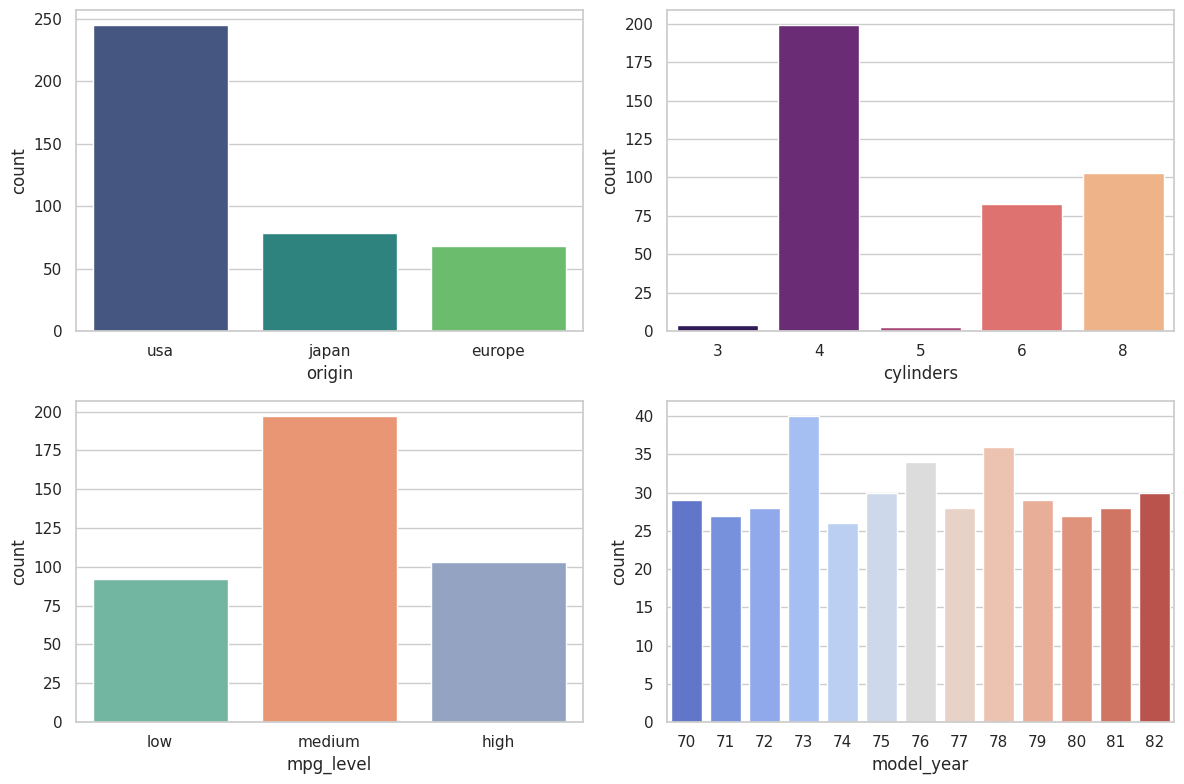

In [11]:
# TODO: Plot a countplot for each of: origin, cylinders, mpg_level, model_year
# Arrange them in a 2×2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Use hue to color the bars and legend=False to keep the plots clean
sns.countplot(data=df, x='origin', hue='origin', palette='viridis', legend=False, ax=axes[0, 0])
sns.countplot(data=df, x='cylinders', hue='cylinders', palette='magma', legend=False, ax=axes[0, 1])
sns.countplot(data=df, x='mpg_level', hue='mpg_level', palette='Set2', legend=False, ax=axes[1, 0])
sns.countplot(data=df, x='model_year', hue='model_year', palette='coolwarm', legend=False, ax=axes[1, 1])

plt.tight_layout()
plt.show()

In [12]:
# TODO: Print the proportion (%) of the dominant class for
# origin, cylinders, and mpg_level
for col in ['origin', 'cylinders', 'mpg_level']:
    # normalize=True gives proportions instead of raw counts
    proportions = df[col].value_counts(normalize=True) * 100

    dominant_class = proportions.index[0]
    dominant_pct = proportions.iloc[0]

    print(f"{col}: '{dominant_class}' at {dominant_pct:.1f}%")


origin: 'usa' at 62.5%
cylinders: '4' at 50.8%
mpg_level: 'medium' at 50.3%


origin     europe  japan  usa
cylinders                    
3               0      4    0
4              61     69   69
5               3      0    0
6               4      6   73
8               0      0  103


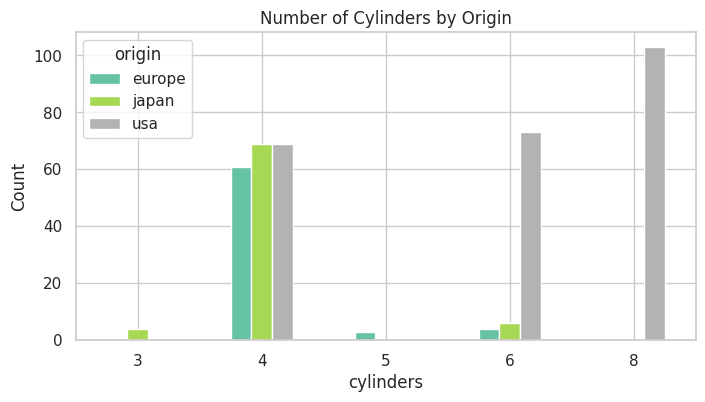

In [13]:
# TODO: Create a crosstab of cylinders vs origin and visualise as a bar chart
# Create the crosstab
crosstab_df = pd.crosstab(df['cylinders'], df['origin'])
print(crosstab_df)

# Visualize as a grouped bar chart
crosstab_df.plot(kind='bar', figsize=(8, 4), colormap='Set2')
plt.title('Number of Cylinders by Origin')
plt.ylabel('Count')
plt.xticks(rotation=0) # Keeps cylinder labels horizontal
plt.show()


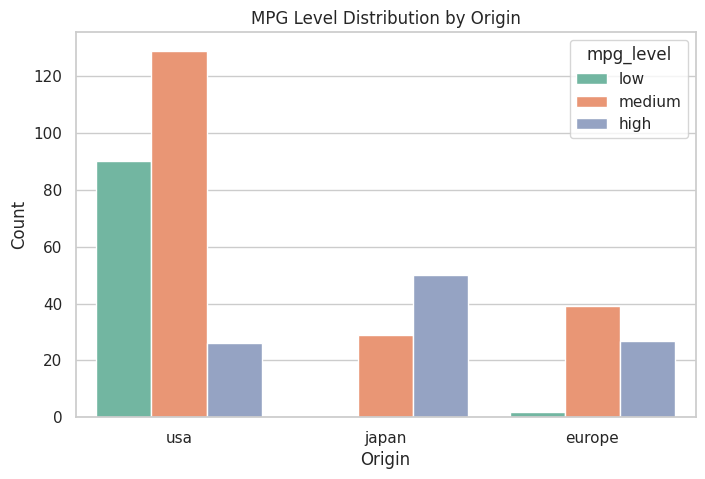

In [16]:
# TODO: Plot a countplot of mpg_level grouped by origin (use hue='mpg_level')

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='origin', hue='mpg_level', palette='Set2')

plt.title('MPG Level Distribution by Origin')
plt.xlabel('Origin')
plt.ylabel('Count')
plt.show()

**Q3.** Which origin has **no** vehicles with low mpg_level?  
**Answer:** JAPAN

**Q4.** Which cylinder count is most common, and what percentage does it represent?  
**Answer:** 4 Clydiner and representing 50%.


## Task 6 — Numerical EDA

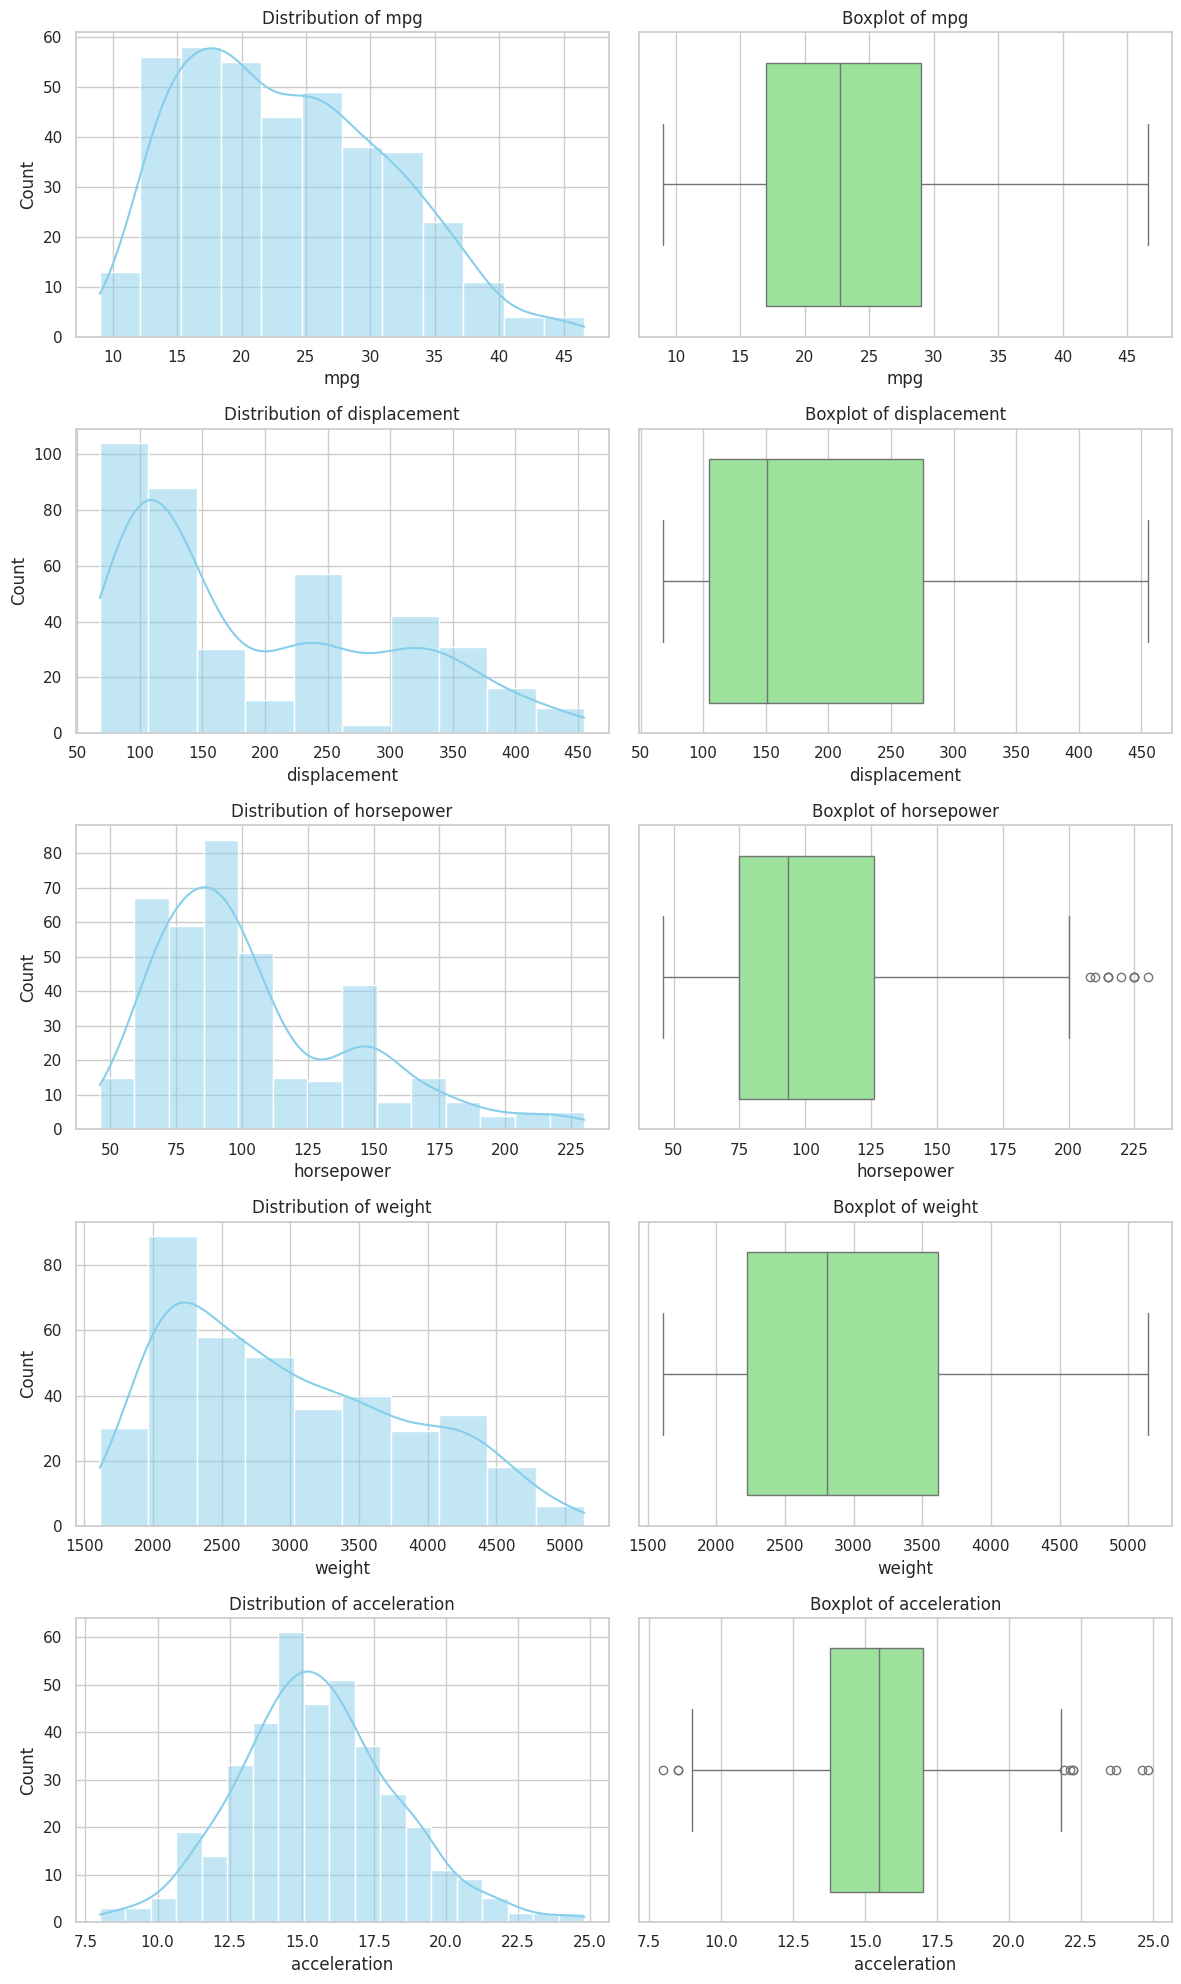

In [17]:
# TODO: For each numerical column plot:
n_rows = len(num_cols)
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows))

for i, col in enumerate(num_cols):
    # (a) Histogram + KDE
    sns.histplot(data=df, x=col, kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribution of {col}')

    # (b) Boxplot
    sns.boxplot(data=df, x=col, ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


In [18]:
# TODO: Write a function tukey_outliers(series) that returns the outlier values
# using the IQR (Tukey) rule: Q1 - 1.5*IQR  and  Q3 + 1.5*IQR
# Then print the outlier count for each numerical column

def tukey_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers

# Print the outlier count for each numerical column
for col in num_cols:
    outliers = tukey_outliers(df[col])
    print(f"{col} outliers: {len(outliers)}")



mpg outliers: 0
displacement outliers: 0
horsepower outliers: 10
weight outliers: 0
acceleration outliers: 11


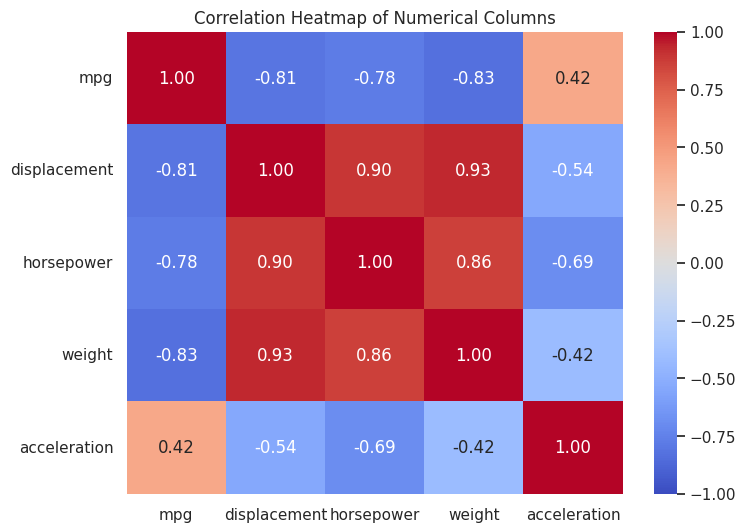

In [21]:
# TODO: Plot a correlation heatmap for all numerical columns (use annot=True)
plt.figure(figsize=(8, 6))
corr_matrix = df[num_cols].corr()

# Create the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)

plt.title('Correlation Heatmap of Numerical Columns')
plt.show()


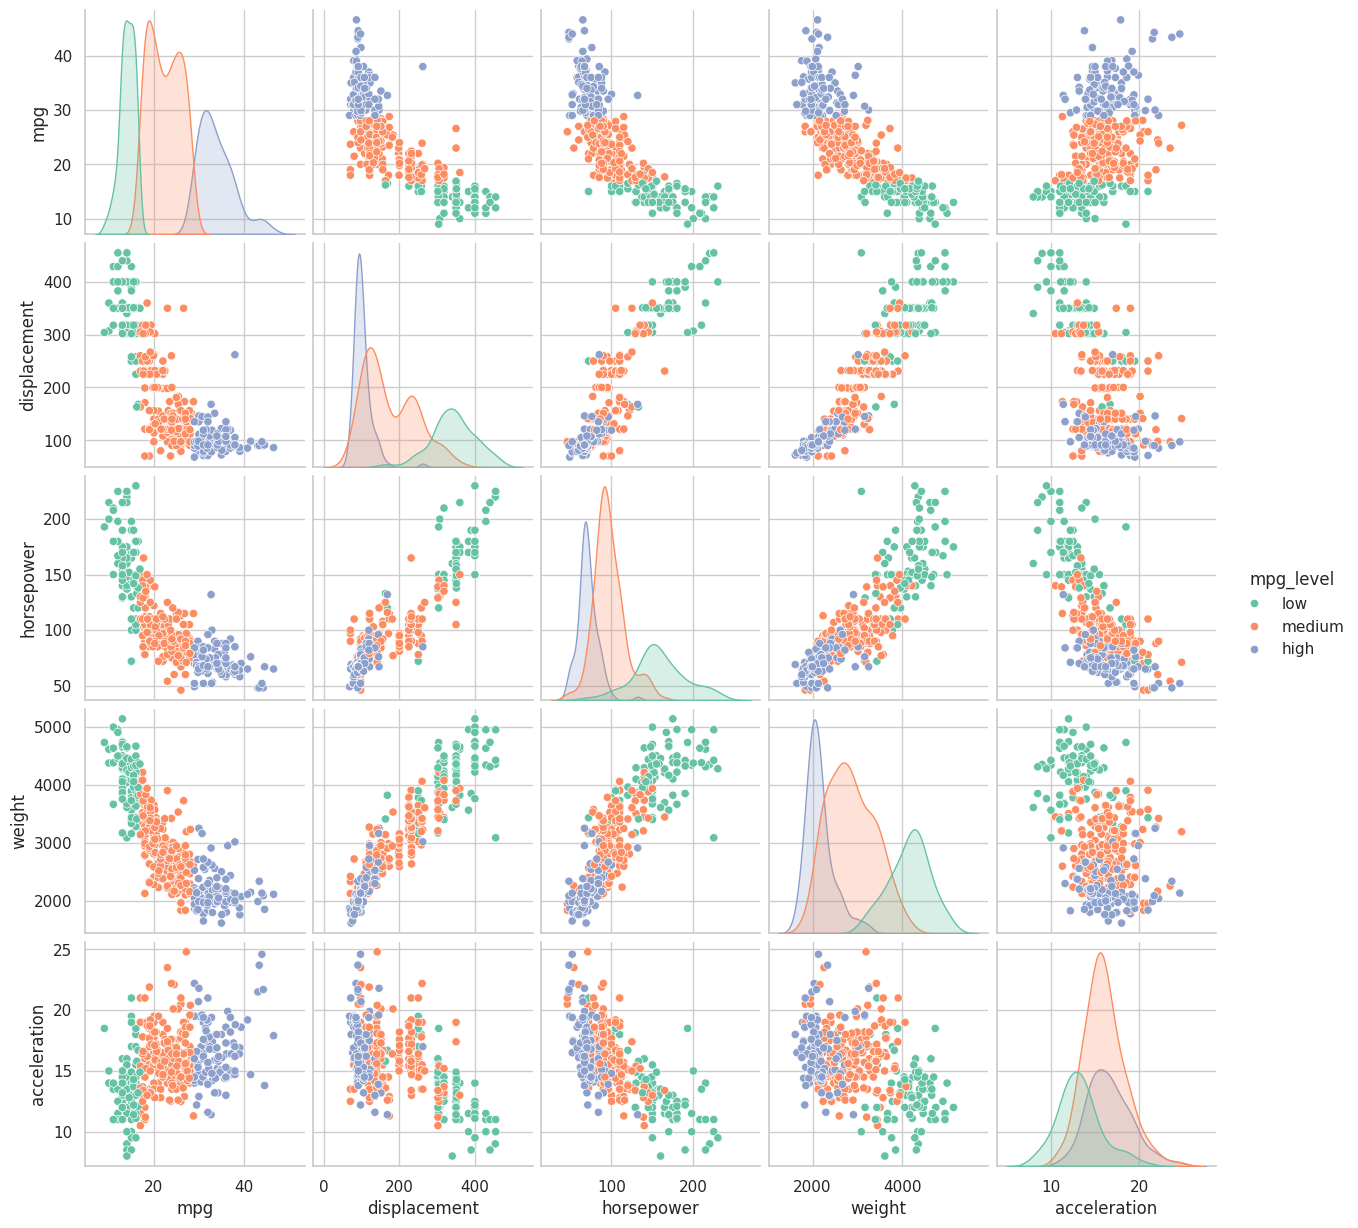

In [23]:
# TODO: Create a pairplot of numerical columns, coloured by mpg_level
sns.pairplot(data=df, vars=num_cols, hue='mpg_level', palette='Set2')
plt.show()


**Q5.** Which two numerical features have the strongest negative correlation with mpg?  
**Answer:**  Weight and Displacement

**Q6.** Is the `acceleration` distribution approximately Gaussian? Justify briefly.  
**Answer:** Yes. It forms a fairly symmetric, bell-shaped distribution centered around its mean (~15.5 seconds) with minimal skewness compared to the other right-skewed numerical features.


## Task 7 — Numerical vs Categorical

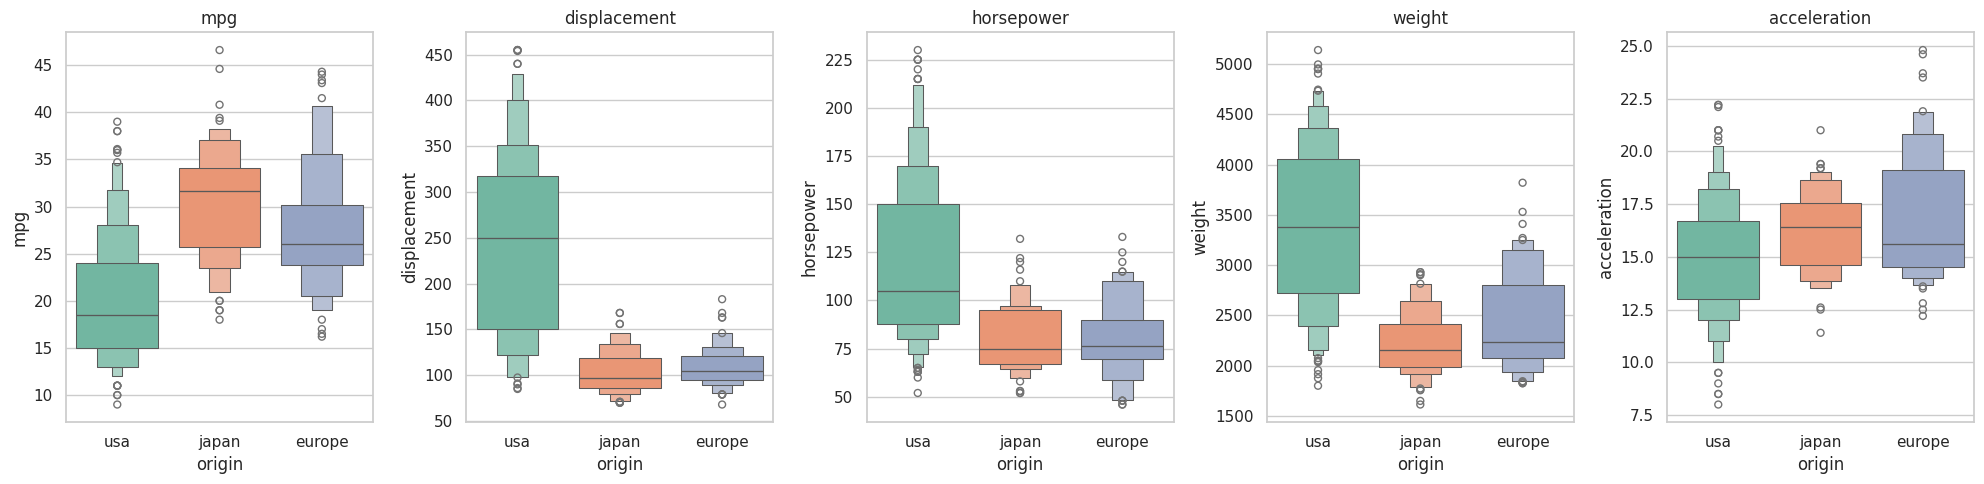

In [28]:
# TODO: Plot boxenplots of all numerical features grouped by 'origin'
# (1 row × 5 column subplot grid)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(num_cols):
    sns.boxenplot(data=df, x='origin', y=col, hue='origin', legend=False, ax=axes[i], palette='Set2')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


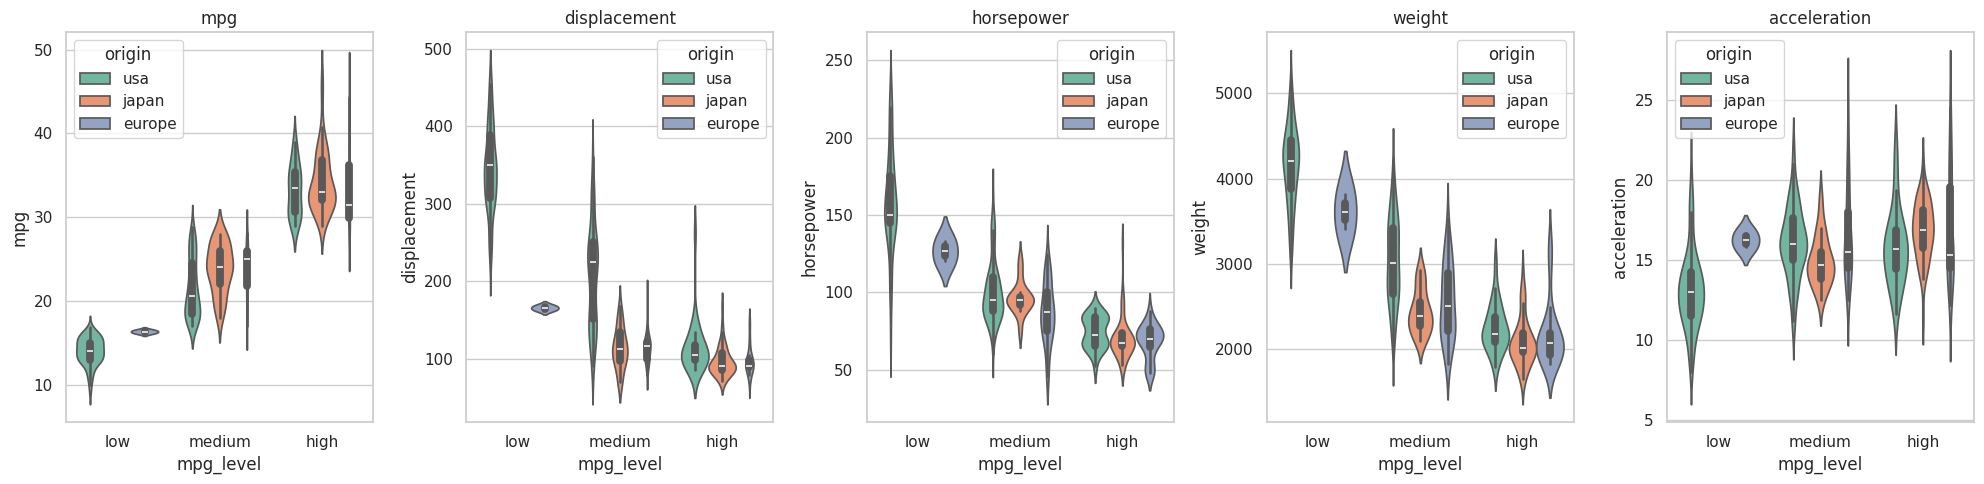

In [30]:
# TODO: Plot violinplots of all numerical features grouped by 'mpg_level'
n_cols = len(num_cols)
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 5))

for i, col in enumerate(num_cols):
    sns.violinplot(data=df, x='mpg_level', hue='origin', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


/tmp/ipykernel_867/3995756857.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_mpg = df.groupby('model_year')['mpg'].mean().reset_index()


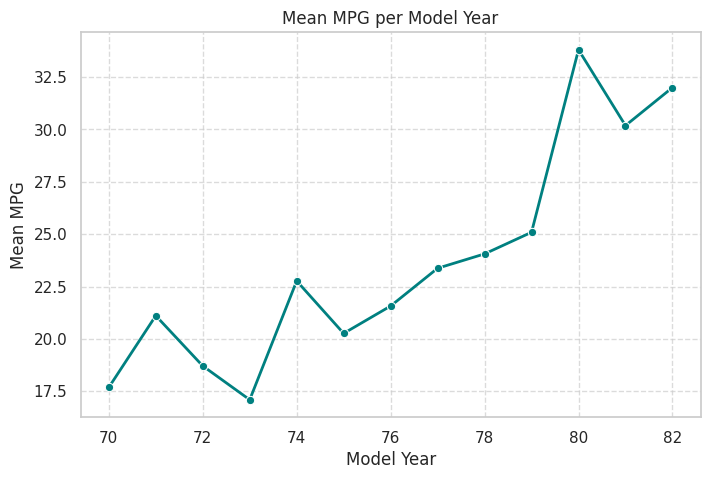

In [31]:
# TODO: Plot a line chart showing mean mpg per model_year
mean_mpg = df.groupby('model_year')['mpg'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(data=mean_mpg, x='model_year', y='mpg', marker='o', color='teal', linewidth=2)

plt.title('Mean MPG per Model Year')
plt.xlabel('Model Year')
plt.ylabel('Mean MPG')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


**Q7.** On average, which origin produces cars with the lowest mpg?  
**Answer:** USA

**Q8.** Describe in one sentence how mpg changes as model_year increases.  
**Answer:** As the model year increases, the average mpg generally shows a steady upward trend as vehicles become more fuel-efficient.


## Task 8 — Summary Table
Fill in the table below based on your analysis.

| Feature | Relationship with MPG | Strength |
|---|---|---|
| displacement | | |
| horsepower | | |
| weight | | |
| acceleration | | |
| cylinders | | |
| origin | | |
| model_year | | |
